1. **Monte um passo a passo para o Bagging**
2. **Explique com suas palavras o Bagging**
3. **Implementar em python o código do Bagging**

    1. Bootstrap
    2. Modelagem
    3. Agregação

### **1**

**Passo a Passo para o Bagging:**

1. **Preparação dos Dados**: Com o conjunto de dados original em mãos, geram-se subconjuntos secundários por meio de uma amostragem com reposição. Cada um desses subconjuntos será utilizado para treinar um modelo distinto.
2. **Base Learners**: São criados e treinados modelos diferentes para cada subconjunto de dados, conhecidos como *base learners*. Cada modelo aprende a partir de um conjunto de dados distinto, com o objetivo de capturar diferentes aspectos do problema.
3. **Agregação**: Na etapa de agregação, as previsões dos modelos são combinadas para gerar a resposta final. Para problemas de classificação, a resposta do conjunto de modelos é determinada pela frequência das respostas, ou seja, pela *votação* dos modelos. Já para problemas de regressão, a resposta final é obtida pela média das previsões de cada modelo.

Esta método reduz significativamente a chance de overfitting.

### **2**

Bagging é uma técnica que se baseia em três ideias principais. Primeiro, na **preparação dos dados**, o conjunto de dados original é dividido em subconjuntos (datasets secundários) usando amostragem com reposição. Isso cria diferentes versões dos dados para treinar os modelos. Depois, temos os **base learners**, que são os modelos criados a partir desses subconjuntos. Cada um gera uma resposta diferente, o que ajuda a reduzir o risco de overfitting. Por fim, na parte de **agregação**, as previsões dos modelos são combinadas para gerar a resposta final. Se for um problema de classificação, a resposta final vem da votação entre os modelos, e se for de regressão, a média das previsões é que define a resposta. A ideia do Bagging é juntar vários modelos para que, no final, o modelo final seja mais robusto e menos propenso a erros.

### **3**

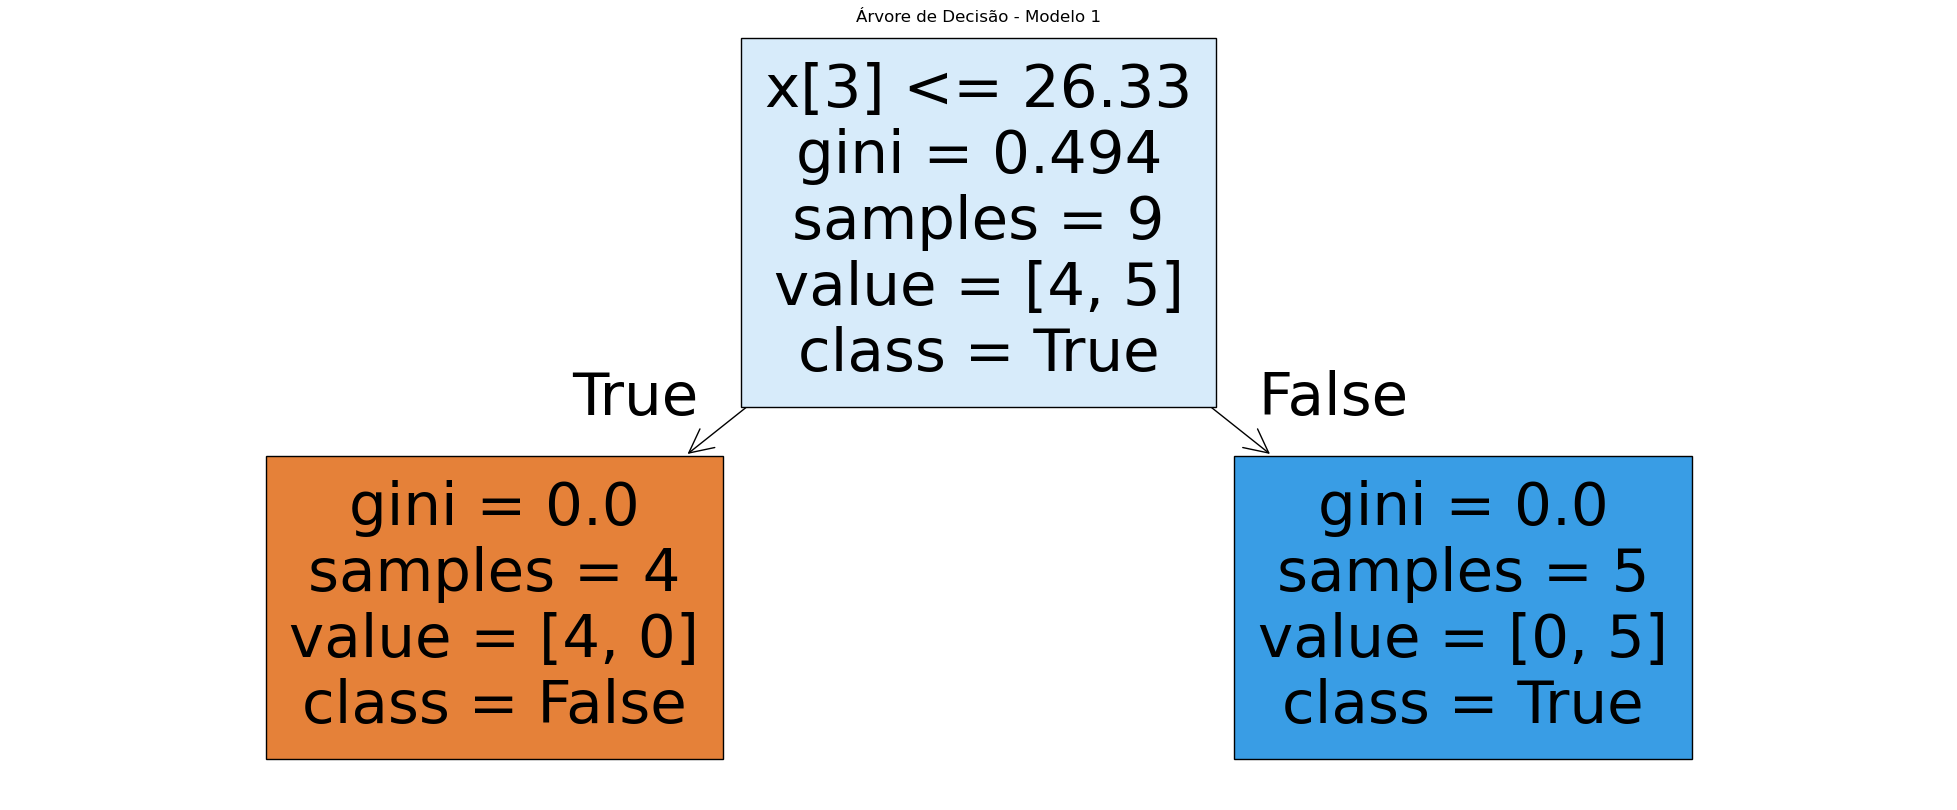

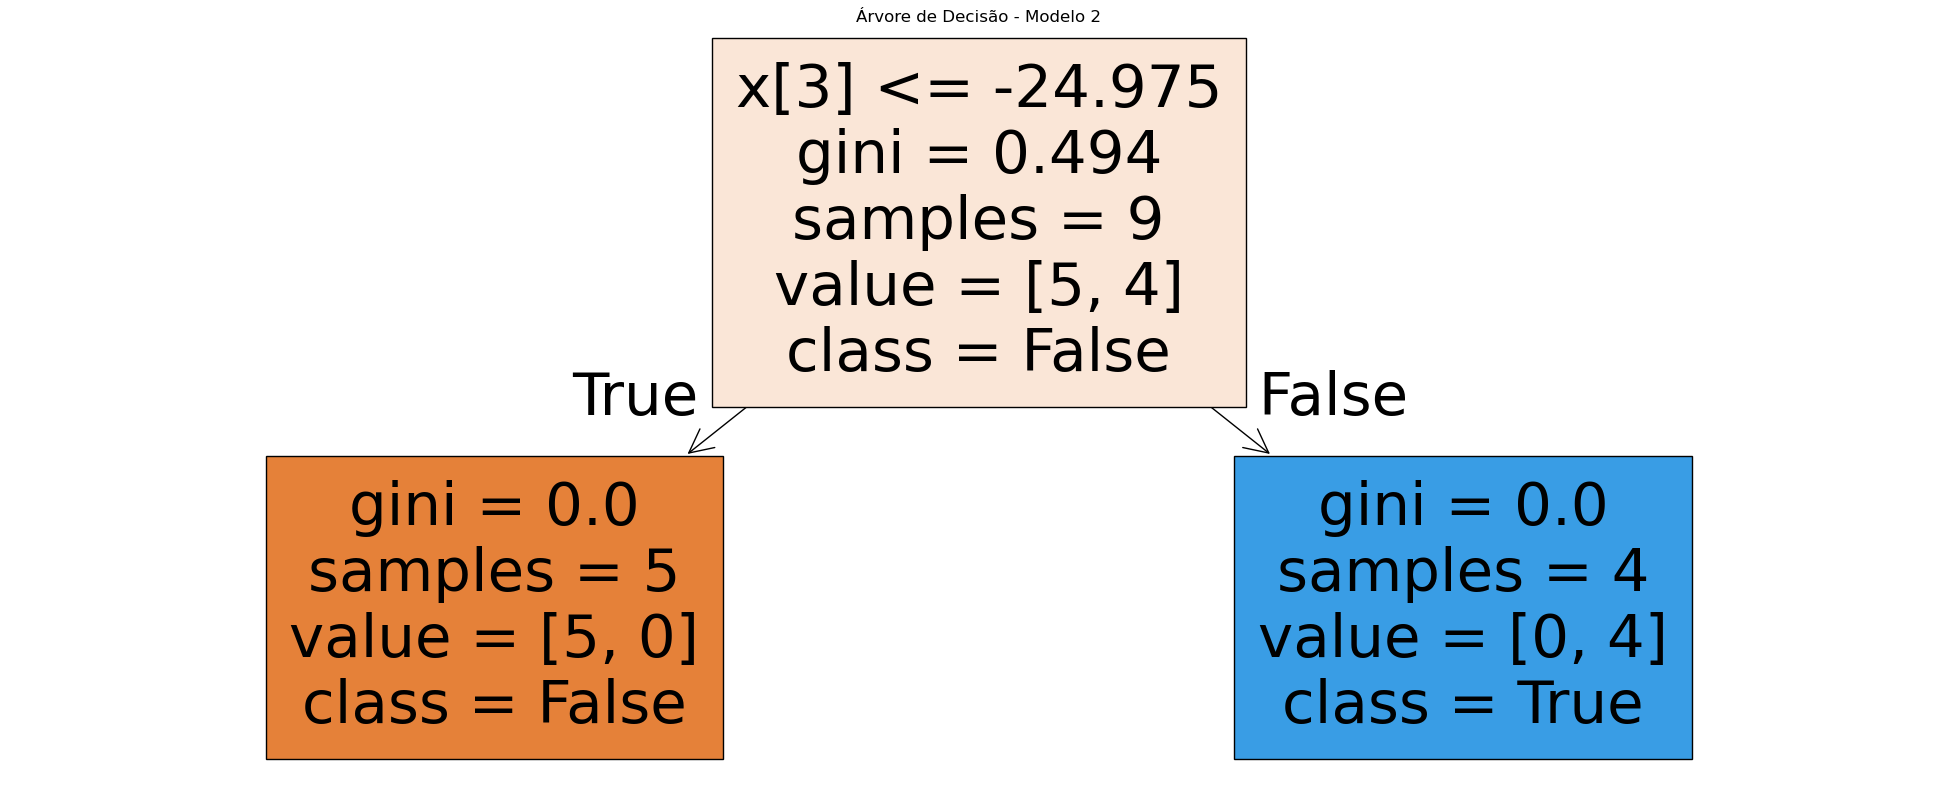

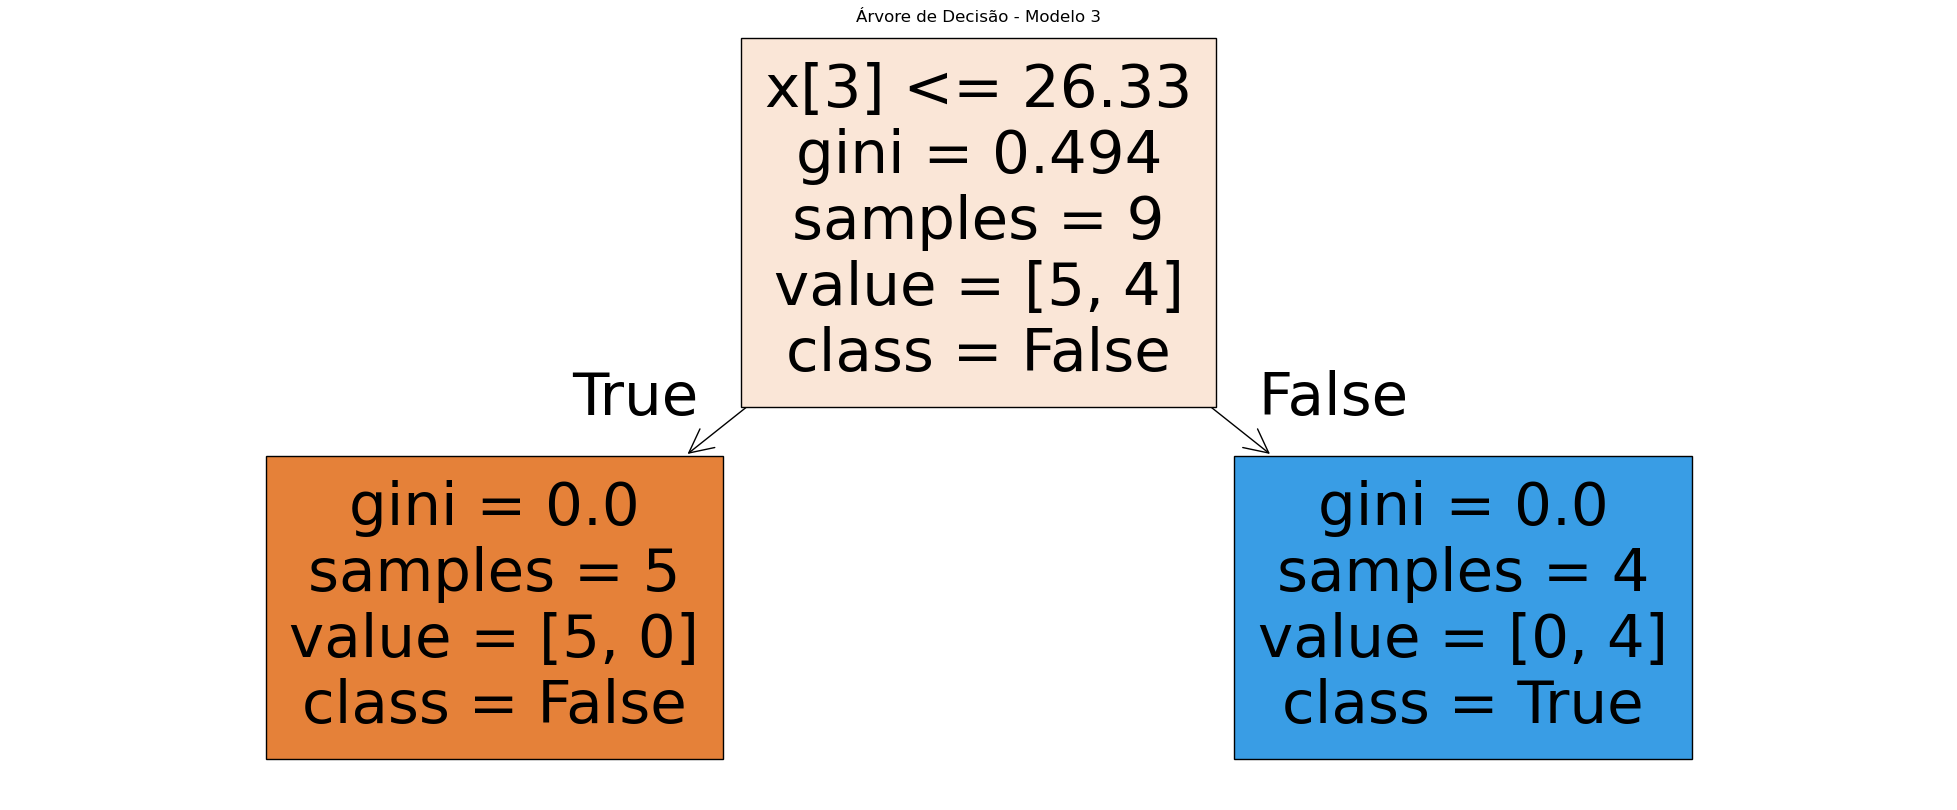

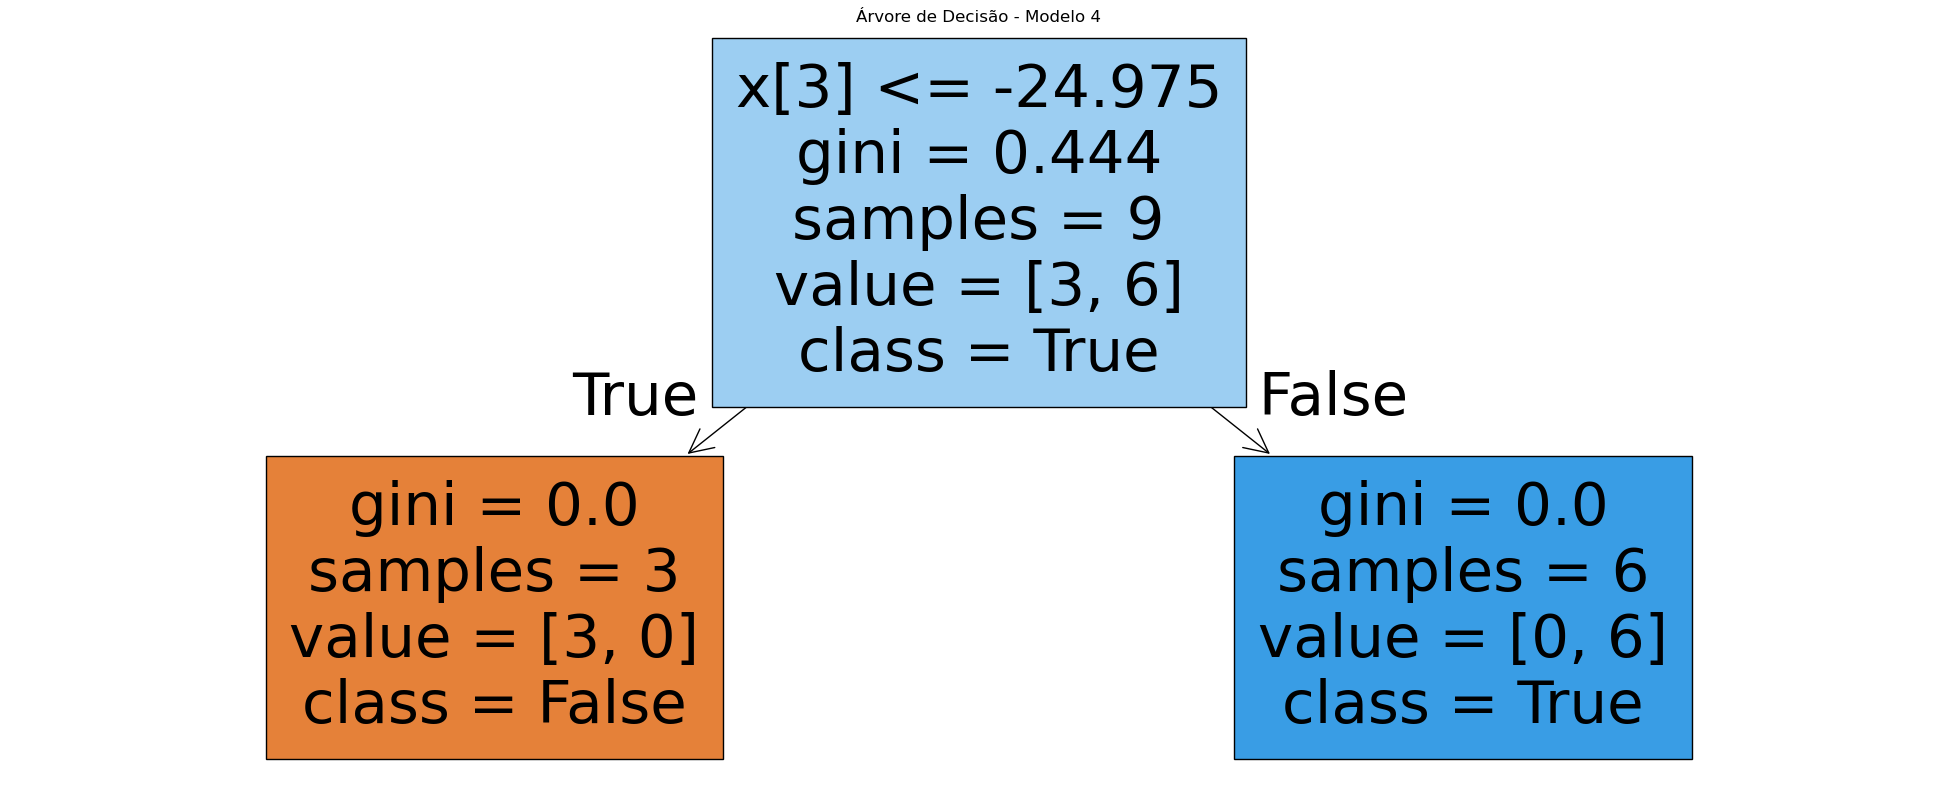

Previsões finais (votação da maioria): [0 0 0 0 1 0 1 1 0]


In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from scipy.stats import mode

# Criação de um DataFrame com valores aleatórios e colunas nomeadas
df = pd.DataFrame(
    np.random.randn(9, 4) * 100,  # Gera uma matriz 9x4 de números aleatórios multiplicados por 100
    columns=["coluna1", "coluna2", "coluna3", "coluna4"],  # Nome das colunas
)

# Criando um novo conjunto de teste com dados aleatórios
teste = pd.DataFrame(
    np.random.randn(9, 4) * 100, 
    columns=["coluna1", "coluna2", "coluna3", "coluna4"]
)

# Adiciona uma coluna 'Interesse' com valores booleanos aleatórios
df['Interesse'] = np.random.choice([True, False], size=(9,))

# Realiza amostragem com reposição para criar subconjuntos de dados
amostragem1 = df.sample(n=9, replace=True, random_state=100)
amostragem2 = df.sample(n=9, replace=True, random_state=101)
amostragem3 = df.sample(n=9, replace=True, random_state=102)
amostragem4 = df.sample(n=9, replace=True, random_state=103)

# Separa as variáveis independentes (features) de cada amostragem
x_amostragem1 = amostragem1[['coluna1', 'coluna2', 'coluna3', 'coluna4']]
x_amostragem2 = amostragem2[['coluna1', 'coluna2', 'coluna3', 'coluna4']]
x_amostragem3 = amostragem3[['coluna1', 'coluna2', 'coluna3', 'coluna4']]
x_amostragem4 = amostragem4[['coluna1', 'coluna2', 'coluna3', 'coluna4']]

# Separa a variável dependente (target) de cada amostragem
y_amostragem1 = amostragem1['Interesse']
y_amostragem2 = amostragem2['Interesse']
y_amostragem3 = amostragem3['Interesse']
y_amostragem4 = amostragem4['Interesse']

# Criação de modelos de árvore de decisão para cada amostragem
clf1 = DecisionTreeClassifier(random_state=100, max_depth=2)
clf2 = DecisionTreeClassifier(random_state=101, max_depth=2)
clf3 = DecisionTreeClassifier(random_state=102, max_depth=2)
clf4 = DecisionTreeClassifier(random_state=103, max_depth=2)

# Treinamento dos modelos com os dados de cada amostragem
clf1 = clf1.fit(x_amostragem1, y_amostragem1)
clf2 = clf2.fit(x_amostragem2, y_amostragem2)
clf3 = clf3.fit(x_amostragem3, y_amostragem3)
clf4 = clf4.fit(x_amostragem4, y_amostragem4)

# Visualização da árvore de decisão do primeiro modelo
arvore1 = plt.figure(figsize=(25, 10))
plot_tree(
    clf1,
    filled=True,  # Preenche os nós com cores baseadas nas classes
    class_names=['False', 'True'],  # Nomes das classes
)
plt.title("Árvore de Decisão - Modelo 1")
plt.show()

# Visualização da árvore de decisão do segundo modelo
arvore2 = plt.figure(figsize=(25, 10))
plot_tree(
    clf2,
    filled=True,
    class_names=['False', 'True'],
)
plt.title("Árvore de Decisão - Modelo 2")
plt.show()

# Visualização da árvore de decisão do terceiro modelo
arvore3 = plt.figure(figsize=(25, 10))
plot_tree(
    clf3,
    filled=True,
    class_names=['False', 'True'],
)
plt.title("Árvore de Decisão - Modelo 3")
plt.show()

# Visualização da árvore de decisão do quarto modelo
arvore4 = plt.figure(figsize=(25, 10))
plot_tree(
    clf4,
    filled=True,
    class_names=['False', 'True'],
)
plt.title("Árvore de Decisão - Modelo 4")
plt.show()

# Previsões dos modelos para o conjunto de teste
pred1 = clf1.predict(teste)
pred2 = clf2.predict(teste)
pred3 = clf3.predict(teste)
pred4 = clf4.predict(teste)

# Converte de booleano para inteiro
pred1 = pred1.astype(int)
pred2 = pred2.astype(int)
pred3 = pred3.astype(int)
pred4 = pred4.astype(int)

# Empilha as previsões (linhas: modelos, colunas: amostras)
todas_predicoes = np.vstack([pred1, pred2, pred3, pred4])

# Aplica a votação por maioria (ao longo das linhas)
predicao_final, _ = mode(todas_predicoes, axis=0, keepdims=False)

# Exibe as previsões finais
print("Previsões finais (votação da maioria):", predicao_final)